# Awareness Factor Investigation 

These are experimental codes:      
- Briefing the data
- Tuning optimal hyperparameter
- Visualize the performance of Models
- Visualize the importance
- Visualize and summerize impacts

In [1]:
%pwd

'/mnt/d/OneDrive/MLD01_Article/MLD01e_Code'

In [2]:
%cd ..

/mnt/d/OneDrive/MLD01_Article


/home/linux/anaconda3/envs/tf/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


## Import PAckage

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from xgboost import XGBClassifier 

## Append Data

In [4]:
df_2016 = pd.read_parquet('Data/01_Napel2016.parquet')
df_2016['Year'] = 2016
df_2022 = pd.read_parquet('Data/01_Napel2022.parquet')
df_2022['Year'] = 2022

In [5]:
df_all = pd.concat([df_2016, df_2022], axis = 0)

In [6]:
df_all.shape

(11568, 352)

In [7]:
df_all = df_all.dropna(axis=1, how="any")

In [8]:
df_all.shape

(11568, 277)

In [9]:
df_all = df_all.set_index(['PSU', 'HHLD'])

In [10]:
df_all.columns

Index(['EcoBelt', 'Prov', 'Rural_Dummy', 'Respon_Female', 'Respon_Age',
       'LivingYear', 'Edu_UnderSLC', 'Edu_Certificate', 'Edu_Bachelor',
       'Edu_Master',
       ...
       'SoilWaterConservationPast25', 'VisitClimateOfficePast25',
       'FoodConsumptionHabitPast25', 'OfffarmActiPast25',
       'NonFarmEmployPast25', 'FamilyMigrationPast25', 'RiskReductionPast25',
       'RoadImprovementPast25', 'CommunityPartipationPast25', 'Year'],
      dtype='object', length=275)

In [11]:
df_all["EcoBelt"] = df_all["EcoBelt"].str.replace('Tarai', 'Terai')

In [12]:
eco_dummies = pd.get_dummies(df_all["EcoBelt"], prefix="EcoBelt").astype(int)
df_all = pd.concat([df_all, eco_dummies], axis=1)

In [13]:
prov_dummies = pd.get_dummies(df_all["Prov"], prefix="Prov").astype(int)
df_all = pd.concat([df_all, prov_dummies], axis=1)

In [14]:
df_all

EcoBelt          Prov  Rural_Dummy  Respon_Female  Respon_Age  \
PSU   HHLD                                                                   
101.0 1.0   Mountain         Koshi            1            1.0        49.0   
      2.0   Mountain         Koshi            1            0.0        55.0   
      3.0   Mountain         Koshi            1            1.0        46.0   
      4.0   Mountain         Koshi            1            0.0        78.0   
      5.0   Mountain         Koshi            1            0.0        70.0   
...              ...           ...          ...            ...         ...   
826.0 16.0     Terai  Sudurpaschim            0            0.0        47.0   
      17.0     Terai  Sudurpaschim            0            0.0        60.0   
      18.0     Terai  Sudurpaschim            0            1.0        47.0   
      19.0     Terai  Sudurpaschim            0            0.0        55.0   
      20.0     Terai  Sudurpaschim            0            0.0        45.0   

            LivingYear  Edu_UnderSLC  Edu_Certificate  Edu_Bachelor  \
PSU   HHLD                                                            
101.0 1.0         49.0             0                0             0   
      2.0         55.0             1                0             0   
      3.0         25.0             0                0             0   
      4.0         78.0             0                0             0   
      5.0         70.0             1                0             0   
...                ...           ...              ...           ...   
826.0 16.0        40.0             1                0             0   
      17.0        35.0             0                0             0   
      18.0        32.0             1                0             0   
      19.0        55.0             0                0             0   
      20.0        25.0             1                0             0   

            Edu_Master  ...  EcoBelt_Hill  EcoBelt_Mountain  EcoBelt_Terai  \
PSU   HHLD              ...                                                  
101.0 1.0            0  ...             0                 1              0   
      2.0            0  ...             0                 1              0   
      3.0            0  ...             0                 1              0   
      4.0            0  ...             0                 1              0   
      5.0            0  ...             0                 1              0   
...                ...  ...           ...               ...            ...   
826.0 16.0           0  ...             0                 0              1   
      17.0           0  ...             0                 0              1   
      18.0           0  ...             0                 0              1   
      19.0           0  ...             0                 0              1   
      20.0           0  ...             0                 0              1   

            Prov_Bagmati  Prov_Gandaki  Prov_Karnali  Prov_Koshi  \
PSU   HHLD                                                         
101.0 1.0              0             0             0           1   
      2.0              0             0             0           1   
      3.0              0             0             0           1   
      4.0              0             0             0           1   
      5.0              0             0             0           1   
...                  ...           ...           ...         ...   
826.0 16.0             0             0             0           0   
      17.0             0             0             0           0   
      18.0             0             0             0           0   
      19.0             0             0             0           0   
      20.0             0             0             0           0   

            Prov_Lumbini  Prov_Madhesh  Prov_Sudurpaschim  
PSU   HHLD                                                 
101.0 1.0              0             0                

### Revise Income Resources

In [15]:
df_all['IncomeResAgri_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 1).any(axis=1).astype(int)
df_all['IncomeResWage_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 2).any(axis=1).astype(int)
df_all['IncomeResNonAgriBusi_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 3).any(axis=1).astype(int)
df_all['IncomeResRemit_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 4).any(axis=1).astype(int)
df_all['IncomeResOthers_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 5).any(axis=1).astype(int)

In [16]:
df_all['ResidenceOwn_dummy'] = (df_all['Own_Resid'] == 1).astype(int)
df_all['ResidenceRent_dummy'] = (df_all['Own_Resid'] == 2).astype(int)
df_all['ResidenceInstitu_dummy'] = (df_all['Own_Resid'] == 3).astype(int)
df_all['ResidenceOthers_dummy'] = (df_all['Own_Resid'] == 4).astype(int)

In [17]:
df_all['ResidInfraPerman_dummy'] = (df_all['Resid_Type'] == 1).astype(int)
df_all['ResidInfraSemi_dummy'] = (df_all['Resid_Type'] == 2).astype(int)
df_all['ResidInfraKachchi_dummy'] = (df_all['Resid_Type'] == 3).astype(int)
df_all['ResidInfraOthers_dummy'] = (df_all['Resid_Type'] == 4).astype(int)

## Checking "HeardClimate_Dummy"

### Dataset building

In [18]:
for here in range(0, df_all.shape[1], 40):
    print(df_all.columns[0+here:40+here])

Index(['EcoBelt', 'Prov', 'Rural_Dummy', 'Respon_Female', 'Respon_Age',
       'LivingYear', 'Edu_UnderSLC', 'Edu_Certificate', 'Edu_Bachelor',
       'Edu_Master', 'Edu_PhD', 'Edu_Literal', 'Edu_Illiterate', 'Edu_year',
       'Female_Ratio', 'U18_Ratio', 'A65_Ratio', 'Edu12_Ratio',
       'Literal_Ratio', 'Household_memberNum', 'Own_Resid', 'Resid_Type',
       'WaterS1', 'WaterS2', 'WaterS3', 'CookFuelS1', 'CookFuelS2',
       'CookFuelS3', 'LightEnergy', 'Toilet', 'IncomeS1', 'IncomeS2',
       'IncomeS3', 'Remittance_dummy', 'Have_AgriLand', 'Radio_dummy',
       'TV_dummy', 'PC_dummy', 'Net_dummy', 'Phone_dummy'],
      dtype='object')
Index(['Mobile_dummy', 'Motorbike_dummy', 'Car_dummy', 'Bike_dummy',
       'OtherVehi_dummy', 'Refrige_dummy', 'HouseHead_AgriExpYear',
       'SavingMembership', 'RegularSaving', 'OrgMembership', 'AgriSupport',
       'Dist_Road', 'Dist_HealthCenter', 'Dist_SecondarySchool', 'Dist_Market',
       'Dist_AgriSupport', 'FramMechan', 'CropIncome', 'L

In [40]:
df_inuse = df_all[['ClimateChanged_Dummy', 'HeardClimate_Dummy', 
                   'Respon_Female', 'Respon_Age', 'LivingYear', 'Edu_UnderSLC', 'Edu_Certificate', 
                   'Edu_Bachelor', 'Edu_Master', 'Edu_PhD', 'Edu_Literal', 'Edu_Illiterate', 'Edu_year', # S01
                   'Female_Ratio', 'U18_Ratio', 'A65_Ratio', 'Edu12_Ratio', 'Literal_Ratio', # S02-1
                   'EcoBelt_Hill', 'EcoBelt_Mountain', 'EcoBelt_Terai', 
                   'Prov_Bagmati', 'Prov_Koshi', 'Prov_Lumbini', 'Prov_Madhesh', 'Prov_Sudurpaschim',
                   'Prov_Gandaki', 'Prov_Karnali', # location     
                   'ResidenceOwn_dummy', 'ResidenceRent_dummy', 'ResidenceInstitu_dummy', 'ResidenceOthers_dummy',
                   'ResidInfraPerman_dummy', 'ResidInfraSemi_dummy', 'ResidInfraKachchi_dummy', 'ResidInfraOthers_dummy', # house
                    'Remittance_dummy', 
                   'Have_AgriLand', 'HouseHead_AgriExpYear',
                   'Radio_dummy', 'TV_dummy', 'PC_dummy', 'Net_dummy', 'Phone_dummy',
                   'Mobile_dummy', 'Motorbike_dummy', 'Car_dummy', 'Bike_dummy', 'OtherVehi_dummy', 'Refrige_dummy',
                   'SavingMembership', 'RegularSaving', 'OrgMembership', 'AgriSupport', 
                   'Dist_Road', 'Dist_HealthCenter', 'Dist_SecondarySchool', 'Dist_Market', 'Dist_AgriSupport', 
                   'FramMechan',
                    'IncomeResAgri_dummy', 'IncomeResWage_dummy', 'IncomeResNonAgriBusi_dummy', 'IncomeResRemit_dummy',
                   'IncomeResOthers_dummy', 
                   'CropIncome', 'LivestockIncome', 'NonAgriIncome', 'BusiIncome', 'TotalIncome',
                   'Year'
                   
                  ]]

In [41]:
variname_readable = {'ClimateChanged_Dummy':'Climate Change Awareness Dummy',
                     'HeardClimate_Dummy':'Heard about Climate Change Dummy', 'Respon_Female':'Female Dummy', 
                     'Respon_Age':'Age', 'LivingYear':'Years Living in Community', 'Edu_UnderSLC':'Education under Secondary Certificate Dummy', 
                     'Edu_Certificate':'Education with Secondary Certificate Dummy', 'Edu_Bachelor':'Education with Bachelor Dummy', 
                     'Edu_Master':'Education with Master Dummy',  'Edu_PhD':'Education with PhD Dummy', 
                     'Edu_Literal':'Literate Education Dummy',  'Edu_Illiterate':'Illiterate Dummy', 'Edu_year':'Education Year',
                     'Female_Ratio':'Female Ratio in Household', 'U18_Ratio':'Member Under 18 Ratio', 'A65_Ratio':'Seniors Ratio',
                     'Edu12_Ratio':"Member with 12-Year Education or above Ratio", "Literal_Ratio": "Literate Member Ratio",
                     'EcoBelt_Hill': "EcoBelt Hill Dummy", 'EcoBelt_Mountain': "EcoBelt Mountain Dummy", 'EcoBelt_Terai': "EcoBelt Terai Dummy",
                     'Prov_Bagmati': "Province Bagmati Dummy", 'Prov_Koshi': "Province Koshi Dummy", 'Prov_Lumbini': "Province Lumbibi Dummy",
                     'Prov_Madhesh': "Province Madhesh Dummy", 'Prov_Sudurpaschim': "Province Sudurpaschim Dummy", 'Prov_Gandaki': "Province Gandaki Dummy",
                     'Prov_Karnali': "Province Karnali Dummy",
                     'ResidenceOwn_dummy': "Owned Residence Ownership Dummy", 'ResidenceRent_dummy': 'Rented Residence Ownership Dummy', 
                     'ResidenceInstitu_dummy': 'Institutional Residence Ownership Dummy', 'ResidenceOthers_dummy': 'Other-type Residence Ownership Dummy',
                     'ResidInfraPerman_dummy': 'Permanent Residence Dummy', 'ResidInfraSemi_dummy': 'Semi-Permanent Residence Dummy', 
                     'ResidInfraKachchi_dummy': "Kachchi Residence Dummy", 'ResidInfraOthers_dummy': 'Other Residence Infrastructure Dummy', # house
                     'Remittance_dummy' : "Have Remittance",
                     'Have_AgriLand': "Having Agricultural Land Dummy", 'HouseHead_AgriExpYear': "Household Head Agricultural Experience",
                     'Radio_dummy': "Having Radio Dummy", 'TV_dummy': "Having TV Dummy", 'PC_dummy': "Having Computer Dummy", 'Net_dummy': "Having Internet Dummy",
                     'Phone_dummy': "Having Telephone Dummy", 'Mobile_dummy': "Having Mobile Dummy", 'Motorbike_dummy': "Having Motorbike Dummy", 
                     'Car_dummy': "Having Car Dummy", 'Bike_dummy': "Having Bike Dummy", 'OtherVehi_dummy': "Having Other Vehicle Dummy", 
                     'Refrige_dummy':"Having Refrigator Dummy",
                     'SavingMembership': "Saving Membership Dummy", 'RegularSaving': 'Having Regular Saving Dummy', 
                     'OrgMembership': 'Having Organization Membership Dummy', 'AgriSupport':'Agricultural Supporting Dummy', 
                     'Dist_Road': 'Distance to Motorable Road', 'Dist_HealthCenter': "Distance to Health Center", 
                     'Dist_SecondarySchool': "Distance to Secondary School", 'Dist_Market':"Distance to Market", 'Dist_AgriSupport': 'Distance to Agricultural Center', 
                     'FramMechan':'Farm Mechanization Dummy',
                     'IncomeResAgri_dummy': "Agricultural Income Source Dummy", 'IncomeResWage_dummy': "Wage Income Source Dummy",
                     'IncomeResNonAgriBusi_dummy': "Non-Agricultural Business Income Source Dummy", 'IncomeResRemit_dummy': "Remittance Income Dummy",
                     'IncomeResOthers_dummy': "Others Income Source Dummy", 
                     'CropIncome': "Crop Income", 'LivestockIncome': "Livestock Income", 'NonAgriIncome': "Non-agricultural Income", 
                     'BusiIncome': "Business Income", 'TotalIncome': "Total Income",
                     'Year': "Survey Year"                    
                    }

In [42]:
data_summary = df_inuse.describe().T

In [43]:
data_summary.index = data_summary.index.map(variname_readable)

In [44]:
data_summary.to_excel("MLD01e_Results/Table03_DataSummaryAwareness_v1.xlsx")

In [45]:
data_summary

,count,mean,std,min,25%,50%,75%,max
Climate Change Awareness Dummy,11568.0,0.901020,2.986480e-01,0.0,1.0,1.0,1.0,1.0
Heard about Climate Change Dummy,11568.0,0.421508,4.938219e-01,0.0,0.0,0.0,1.0,1.0
Female Dummy,11568.0,0.285183,4.515212e-01,0.0,0.0,0.0,1.0,1.0
Age,11568.0,58.681189,1.027651e+01,45.0,50.0,58.0,66.0,95.0
Years Living in Community,11568.0,50.082382,1.582942e+01,25.0,40.0,50.0,60.0,730.0
...,...,...,...,...,...,...,...,...
Livestock Income,11568.0,15559.887275,9.565885e+04,0.0,0.0,0.0,15000.0,7200000.0
Non-agricultural Income,11568.0,79973.158368,2.710275e+05,0.0,0.0,0.0,50000.0,10000000.0
Business Income,11568.0,202175.389004,1.112664e+06,0.0,0.0,15000.0,240000.0,99000000.0
Total Income,11568.0,323942.349066,1.143592e+06,0.0,54000.0,170000.0,400000.0,99200000.0


In [46]:
df_inuse.columns = df_inuse.columns.map(variname_readable)

## Hyper Tunining

In [47]:
y = df_inuse['Climate Change Awareness Dummy'].astype(int)
X = df_inuse.drop(columns=['Climate Change Awareness Dummy'])

pos = y.sum()
neg = len(y) - pos
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

In [48]:
clf = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    device = 'cuda'
)

In [49]:
param_distributions = {
    'n_estimators': [200, 500, 1_000, 2_000],
    'max_depth': [4,  8, 16],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 2, 5, 10]
}

In [50]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_distributions,
    n_iter=200,                 # increase for a more exhaustive search if you have time
    scoring='accuracy',
    return_train_score=True,
    cv=cv,
    verbose=3,
    refit=True,                # refit on entire data with best params
    random_state=42
)

search.fit(X, y)

Fitting 10 folds for each of 200 candidates, totalling 2000 fits


/home/linux/anaconda3/envs/tf/lib/python3.9/site-packages/xgboost/core.py:160: UserWarning: [22:35:41] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


[CV 1/10] END colsample_bytree=0.9, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=1000, subsample=0.7;, score=(train=0.985, test=0.858) total time=   3.9s
[CV 2/10] END colsample_bytree=0.9, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=1000, subsample=0.7;, score=(train=0.985, test=0.868) total time=   3.4s
[CV 3/10] END colsample_bytree=0.9, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=1000, subsample=0.7;, score=(train=0.985, test=0.874) total time=   4.0s
[CV 4/10] END colsample_bytree=0.9, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=1000, subsample=0.7;, score=(train=0.984, test=0.876) total time=   4.3s
[CV 5/10] END colsample_bytree=0.9, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=1000, subsample=0.7;, score=(train=0.985, test=0.864) total time=   4.5s
[CV 6/10] END colsample_bytree=0.9, learning_rate=0.1, max_depth=8, min_child_weight=5, n_estimators=1000, subsample=0.7;, score=(

RandomizedSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device='cuda',
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None, gamma=None,
                                           grow_policy=None,...
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None,
                                           random_state=42, ...),
                   n_iter=200,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [4, 8, 16],
                                        'min_child_weight': [1, 2, 5, 10],
                                        'n_estimators': [200, 500, 1000, 2000],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, return_train_score=True, scoring='accuracy',
                   verbose=3)

In [51]:
# 7) Results
print("Best mean CV accuracy:", f"{search.best_score_:.4f}")
print("Best params:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

Best mean CV accuracy: 0.8919
Best params:
  subsample: 0.9
  n_estimators: 1000
  min_child_weight: 1
  max_depth: 16
  learning_rate: 0.05
  colsample_bytree: 1.0


In [52]:
cvres = pd.DataFrame(search.cv_results_)

In [53]:
cvres.to_parquet('MLD01e_Results/MLD01e_C02_AwarenessFactorInvestigation.parquet')

In [54]:
cols = ['mean_test_score', 'std_test_score', 'rank_test_score'] + [c for c in cvres.columns if c.startswith('param_')]
cvres_sorted = cvres.sort_values('rank_test_score')[cols].head(10)

In [55]:
cvres_sorted

,mean_test_score,std_test_score,rank_test_score,param_subsample,param_n_estimators,param_min_child_weight,param_max_depth,param_learning_rate,param_colsample_bytree
92,0.891944,0.005196,1,0.9,1000,1,16,0.05,1.0
131,0.890128,0.004802,2,0.9,500,1,16,0.1,0.9
108,0.889956,0.007676,3,0.8,1000,1,16,0.05,1.0
88,0.889005,0.006541,4,1.0,2000,1,16,0.1,0.7
102,0.888659,0.006125,5,0.8,2000,1,8,0.1,0.9
2,0.887967,0.005828,6,0.9,2000,1,8,0.05,0.9
161,0.887708,0.006332,7,0.8,2000,1,8,0.05,0.8
56,0.886930,0.006184,8,1.0,1000,2,16,0.1,1.0
120,0.886497,0.006699,9,0.8,2000,1,8,0.1,0.7
25,0.885893,0.006753,10,1.0,2000,2,16,0.1,1.0


## 10-fold 10-epoch Estimation

In [56]:
y = df_inuse['Climate Change Awareness Dummy'].astype(int)
X = df_inuse.drop(columns=['Climate Change Awareness Dummy'])

pos = y.sum()
neg = len(y) - pos
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

In [57]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [58]:
def Metrics(y_test, y_pred):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
    print("F1-score :", f1_score(y_test, y_pred, zero_division=0))

    return [accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, zero_division=0),
    recall_score(y_test, y_pred, zero_division=0), f1_score(y_test, y_pred, zero_division=0)]

In [59]:
prob_matrix = np.zeros([X.shape[0], 10])

In [60]:
acc_lines = []
importances_df = []
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    pos = y_train.sum()
    neg = len(y_train) - pos
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    for random_seed in range(42, 42*11, 42):
        print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(
            n_estimators=1000, max_depth=16,
            learning_rate=0.05, subsample=0.9,
            colsample_bytree=1.0, min_child_weight=1, objective="binary:logistic",
            eval_metric="logloss", tree_method="hist",          
            random_state=random_seed, scale_pos_weight=scale_pos_weight, device = 'cuda'
        )
    
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)


        metrics = Metrics(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred).flatten()
        line  = [fold, random_seed] + metrics + list(cm)
        importances = clf.feature_importances_

        acc_lines.append(line)
        importances_df.append(importances)
        
    

fold: 1, random_seed:42
Accuracy: 0.8928262748487468
Precision: 0.9204025617566332
Recall   : 0.9645254074784276
F1-score : 0.9419475655430711
fold: 1, random_seed:84
Accuracy: 0.8928262748487468
Precision: 0.9242843951985226
Recall   : 0.959731543624161
F1-score : 0.9416745061147695
fold: 1, random_seed:126
Accuracy: 0.8954191875540191
Precision: 0.9244935543278084
Recall   : 0.962607861936721
F1-score : 0.9431658055425082
fold: 1, random_seed:168
Accuracy: 0.898876404494382
Precision: 0.923992673992674
Recall   : 0.9674017257909875
F1-score : 0.9451990632318501
fold: 1, random_seed:210
Accuracy: 0.898876404494382
Precision: 0.9224452554744526
Recall   : 0.9693192713326941
F1-score : 0.9453015427769986
fold: 1, random_seed:252
Accuracy: 0.8971477960242005
Precision: 0.9230769230769231
Recall   : 0.9664429530201343
F1-score : 0.9442622950819672
fold: 1, random_seed:294
Accuracy: 0.8954191875540191
Precision: 0.9229357798165138
Recall   : 0.9645254074784276
F1-score : 0.943272386310361


In [61]:
acc_df = pd.DataFrame(acc_lines)

In [62]:
acc_df.columns = ['fold', 'random_seed', 'acc', 'prec', 'recall', 'f1', 'TN', 'FP', 'FN', 'TP']

In [63]:
acc_df.to_excel('MLD01e_Results/Table04_AccuracyTableAwareness_v1.xlsx')

In [64]:
acc_df[['acc', 'prec', 'recall', 'f1']].mean(axis=0)

acc       0.890837
prec      0.921657
recall    0.960490
f1        0.940666
dtype: float64

In [65]:
import_df = pd.DataFrame(importances_df).T

In [66]:
import_df.index = X.columns

In [67]:
import_df['Mean_Importance'] = import_df.iloc[:,:100].mean(axis = 1)
import_df['Std_Importance'] = import_df.iloc[:,:100].std(axis = 1)

In [68]:
import_df['Mean_Importance'] 

Heard about Climate Change Dummy               0.296524
Female Dummy                                   0.007799
Age                                            0.007810
Years Living in Community                      0.007850
Education under Secondary Certificate Dummy    0.006003
                                                 ...   
Livestock Income                               0.008948
Non-agricultural Income                        0.013367
Business Income                                0.007393
Total Income                                   0.008313
Survey Year                                    0.088850
Name: Mean_Importance, Length: 70, dtype: float32

In [69]:
# Get importance values
importances = pd.Series(import_df['Mean_Importance'] , index=import_df.index)

# Sort descending
importances = importances.sort_values(ascending=False)

print(importances.head(20))   # Top 20 important features

Heard about Climate Change Dummy                0.296524
Survey Year                                     0.088850
Province Madhesh Dummy                          0.031130
Province Gandaki Dummy                          0.023070
Having Mobile Dummy                             0.020975
Education with Bachelor Dummy                   0.017028
Province Karnali Dummy                          0.013759
EcoBelt Terai Dummy                             0.013666
Non-agricultural Income                         0.013367
Province Lumbibi Dummy                          0.013227
Farm Mechanization Dummy                        0.013218
Province Sudurpaschim Dummy                     0.012994
Agricultural Supporting Dummy                   0.012284
Province Koshi Dummy                            0.012071
EcoBelt Mountain Dummy                          0.012024
Owned Residence Ownership Dummy                 0.011191
Province Bagmati Dummy                          0.010845
Member with 12-Year Education o

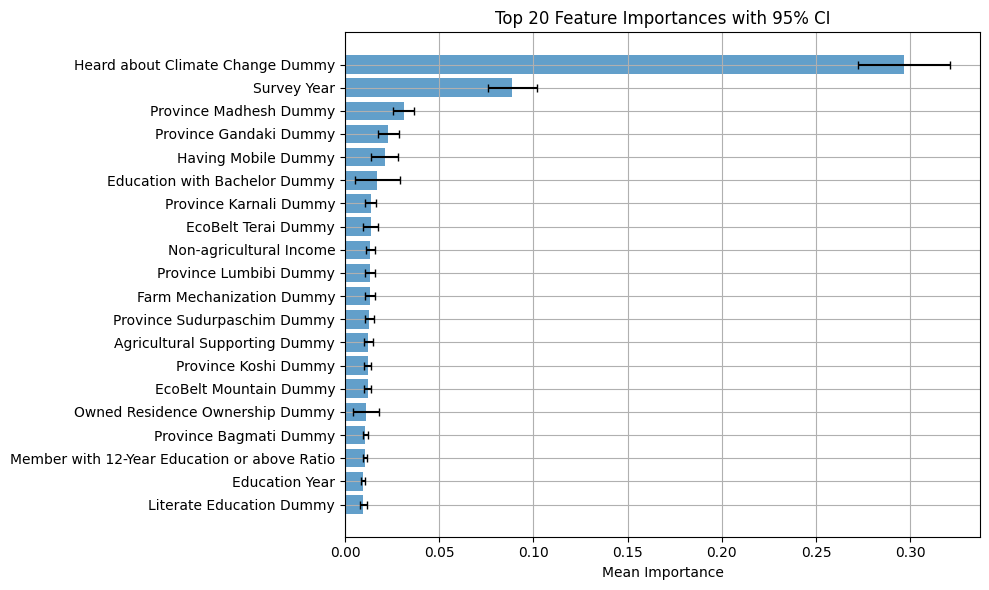

In [70]:
top20 = import_df.sort_values("Mean_Importance", ascending=False).head(20)

plt.figure(figsize=(10,6))
plt.barh(
    top20.index, 
    top20["Mean_Importance"], 
    xerr=top20["Std_Importance"] * 1.96, 
    align="center", 
    alpha=0.7, 
    ecolor="black", 
    capsize=3
)
plt.xlabel("Mean Importance")
plt.title("Top 20 Feature Importances with 95% CI")
plt.grid()
plt.gca().invert_yaxis()  # largest on top
plt.tight_layout()
plt.show()

In [71]:
importances.head(20).index

Index(['Heard about Climate Change Dummy', 'Survey Year',
       'Province Madhesh Dummy', 'Province Gandaki Dummy',
       'Having Mobile Dummy', 'Education with Bachelor Dummy',
       'Province Karnali Dummy', 'EcoBelt Terai Dummy',
       'Non-agricultural Income', 'Province Lumbibi Dummy',
       'Farm Mechanization Dummy', 'Province Sudurpaschim Dummy',
       'Agricultural Supporting Dummy', 'Province Koshi Dummy',
       'EcoBelt Mountain Dummy', 'Owned Residence Ownership Dummy',
       'Province Bagmati Dummy',
       'Member with 12-Year Education or above Ratio', 'Education Year',
       'Literate Education Dummy'],
      dtype='object')

## Compute Impact

### Heard about Climate Change Dummy

In [72]:
name = 'Heard about Climate Change Dummy'

In [73]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))

In [74]:
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    pos = y_train.sum()
    neg = len(y_train) - pos
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    for epoch, random_seed in enumerate(range(42, 42*11, 42)):
        #print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(
            n_estimators=200, max_depth=8,
            learning_rate=0.05, subsample=1.0,
            colsample_bytree=0.7, min_child_weight=10, objective="binary:logistic",
            eval_metric="logloss", tree_method="hist",          
            random_state=random_seed, scale_pos_weight=scale_pos_weight, device = 'cuda'
        )
    
        clf.fit(X_train, y_train)

        # impact
        X_test_tide = X_test.copy()
        X_test_tide[name] = 1
        y_proba_true = clf.predict_proba(X_test_tide)[:, 1]
    
        X_test_tide = X_test.copy()
        X_test_tide[name] = 0
        y_proba_false = clf.predict_proba(X_test_tide)[:, 1]    
    
        y_proba_diff = y_proba_true - y_proba_false
        
        prob_matrix.iloc[test_idx, epoch] = y_proba_diff

In [75]:
prob_matrix.mean().mean()

0.23167930615661386

In [76]:
prob_matrix.mean().std()

0.0013365168306942211

In [77]:
prob_matrix.mean().mean() + 1.96 * prob_matrix.mean().std()

0.23429887914477454

In [78]:
prob_matrix.mean().mean() - 1.96 * prob_matrix.mean().std()

0.22905973316845318

In [79]:
prob_matrix['Mean'] = prob_matrix.mean(axis = 1)

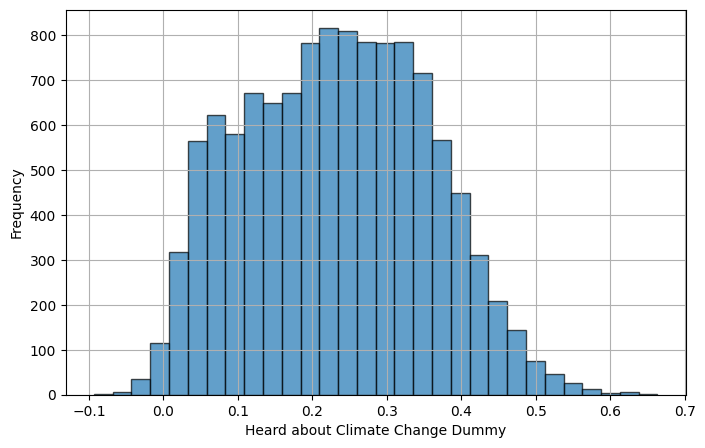

In [80]:
plt.figure(figsize=(8,5))
plt.hist(prob_matrix['Mean'], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel(name)
plt.ylabel("Frequency")
plt.grid()
plt.show()

### Survey Year

In [81]:
name = 'Survey Year'

In [82]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))

In [83]:
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    pos = y_train.sum()
    neg = len(y_train) - pos
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    for epoch, random_seed in enumerate(range(42, 42*11, 42)):
        #print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(
            n_estimators=200, max_depth=8,
            learning_rate=0.05, subsample=1.0,
            colsample_bytree=0.7, min_child_weight=10, objective="binary:logistic",
            eval_metric="logloss", tree_method="hist",          
            random_state=random_seed, scale_pos_weight=scale_pos_weight, device = 'cuda'
        )
    
        clf.fit(X_train, y_train)

        # impact
        X_test_tide = X_test.copy()
        X_test_tide[name] = 2022
        y_proba_true = clf.predict_proba(X_test_tide)[:, 1]
    
        X_test_tide = X_test.copy()
        X_test_tide[name] = 2016
        y_proba_false = clf.predict_proba(X_test_tide)[:, 1]    
    
        y_proba_diff = y_proba_true - y_proba_false
        
        prob_matrix.iloc[test_idx, epoch] = y_proba_diff

In [84]:
prob_matrix.mean().mean()

-0.1146819796581285

In [85]:
prob_matrix.mean().std()

0.009940544633862408

In [86]:
prob_matrix.mean().mean() + 1.96 * prob_matrix.mean().std()

-0.09519851217575818

In [87]:
prob_matrix.mean().mean() - 1.96 * prob_matrix.mean().std()

-0.13416544714049883

In [88]:
prob_matrix['Mean'] = prob_matrix.mean(axis = 1)

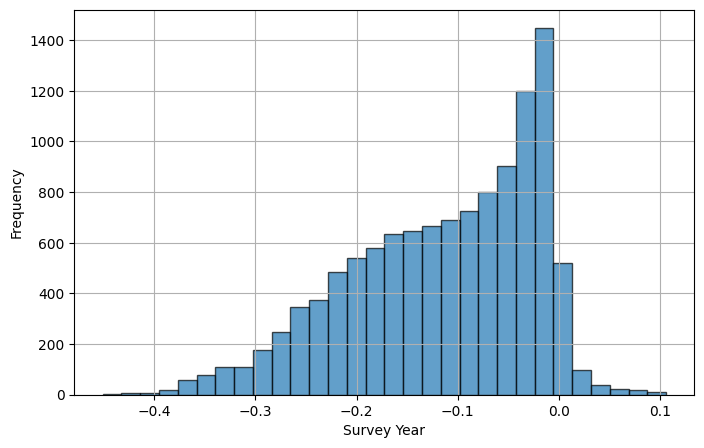

In [89]:
plt.figure(figsize=(8,5))
plt.hist(prob_matrix['Mean'], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel(name)
plt.ylabel("Frequency")
plt.grid()
plt.show()

## Test

### Fit Model

In [23]:
y = df_inuse['HeardClimate_Dummy']
X = df_inuse.drop(columns = ['HeardClimate_Dummy'])

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)

In [25]:
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

pos = y_train.sum()
neg = len(y_train) - pos
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

In [26]:
clf = XGBClassifier(
    n_estimators=1_000,
    max_depth=16,
    learning_rate=0.01,
    subsample=0.7,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",          # fast and memory-efficient
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

In [27]:
clf.fit(
    X_train, y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=16,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [28]:
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
try:
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))
except ValueError:
    # If y is not binary or only one class present in y_test
    pass

Accuracy: 0.7675021607605877
ROC-AUC: 0.8434597760297975


In [29]:
print("\nClassification report:\n", classification_report(y_test, y_pred))


Classification report:
               precision    recall  f1-score   support

           0       0.79      0.82      0.80       669
           1       0.74      0.69      0.72       488

    accuracy                           0.77      1157
   macro avg       0.76      0.76      0.76      1157
weighted avg       0.77      0.77      0.77      1157



Confusion Matrix:
 [[549 120]
 [149 339]]


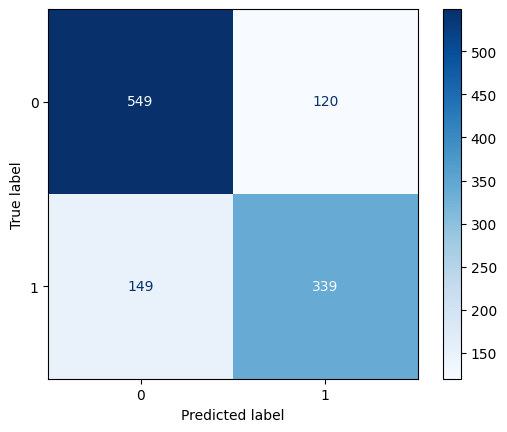

In [30]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)

# Optional: nice plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap="Blues")

### Importance

In [31]:
X_train.columns

Index(['Respon_Female', 'Respon_Age', 'LivingYear', 'Edu_UnderSLC',
       'Edu_Certificate', 'Edu_Bachelor', 'Edu_Master', 'Edu_PhD',
       'Edu_Literal', 'Edu_Illiterate', 'Edu_year', 'Female_Ratio',
       'U18_Ratio', 'A65_Ratio', 'Edu12_Ratio', 'Literal_Ratio',
       'EcoBelt_Hill', 'EcoBelt_Mountain', 'EcoBelt_Terai', 'Prov_Bagmati',
       'Prov_Koshi', 'Prov_Lumbini', 'Prov_Madhesh', 'Prov_Sudurpaschim',
       'Prov_Gandaki', 'Prov_Karnali', 'ResidenceOwn_dummy',
       'ResidenceRent_dummy', 'ResidenceInstitu_dummy',
       'ResidenceOthers_dummy', 'ResidInfraPerman_dummy',
       'ResidInfraSemi_dummy', 'ResidInfraKachchi_dummy',
       'ResidInfraOthers_dummy', 'Remittance_dummy', 'Have_AgriLand',
       'HouseHead_AgriExpYear', 'Radio_dummy', 'TV_dummy', 'PC_dummy',
       'Net_dummy', 'Phone_dummy', 'Mobile_dummy', 'Motorbike_dummy',
       'Car_dummy', 'Bike_dummy', 'OtherVehi_dummy', 'Refrige_dummy',
       'SavingMembership', 'RegularSaving', 'OrgMembership', 'AgriSu

In [33]:
# Get importance values
importances = pd.Series(clf.feature_importances_, index=X_train.columns)

# Sort descending
importances = importances.sort_values(ascending=False)

print(importances.head(20))   # Top 20 important features

PC_dummy                  0.061520
Edu_year                  0.058310
Year                      0.044248
Edu_Illiterate            0.036198
Mobile_dummy              0.023528
Phone_dummy               0.022474
EcoBelt_Terai             0.021797
Prov_Koshi                0.021126
Prov_Karnali              0.019946
Car_dummy                 0.017083
TV_dummy                  0.016104
FramMechan                0.015550
OtherVehi_dummy           0.015068
Refrige_dummy             0.014868
Dist_Road                 0.014607
ResidInfraPerman_dummy    0.014173
CropIncome                0.014036
EcoBelt_Mountain          0.014027
Prov_Madhesh              0.013987
Have_AgriLand             0.013521
dtype: float32


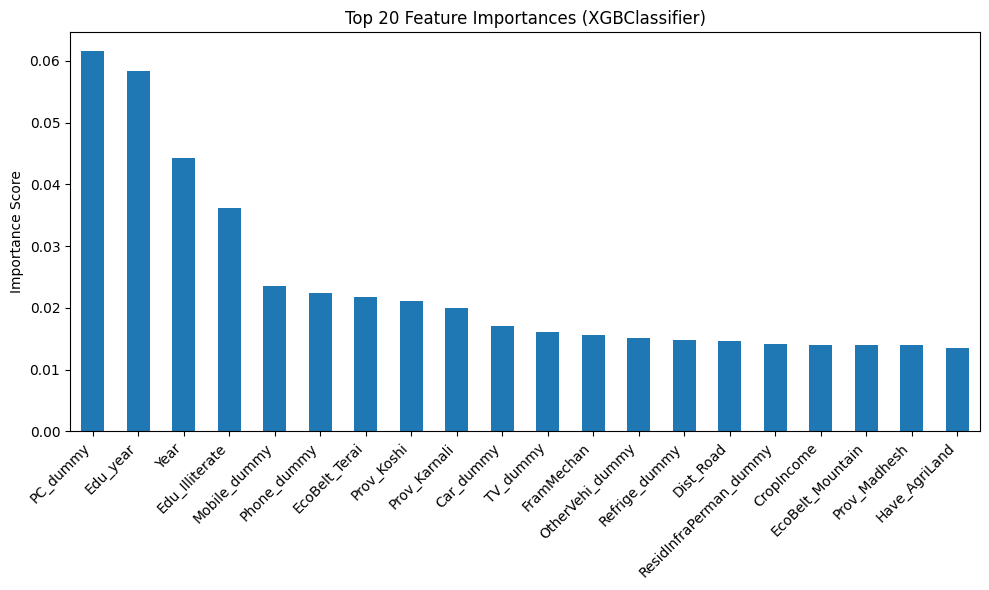

In [34]:
plt.figure(figsize=(10,6))
importances.head(20).plot(kind="bar")
plt.title("Top 20 Feature Importances (XGBClassifier)")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [57]:
importances.head(20).index

Index(['Edu_Illiterate', 'PC_dummy', 'Year', 'Edu_Literal', 'Mobile_dummy',
       'Edu_Certificate', 'Edu12_Ratio', 'Edu_Bachelor', 'Phone_dummy',
       'TV_dummy', 'Edu_UnderSLC', 'Edu_Master', 'Respon_Female', 'Dist_Road',
       'Refrige_dummy', 'CropIncome', 'AgriSupport', 'OtherVehi_dummy',
       'Car_dummy', 'Net_dummy'],
      dtype='object')

### Checking Impacts

Edu_Illiterate, -0.1794


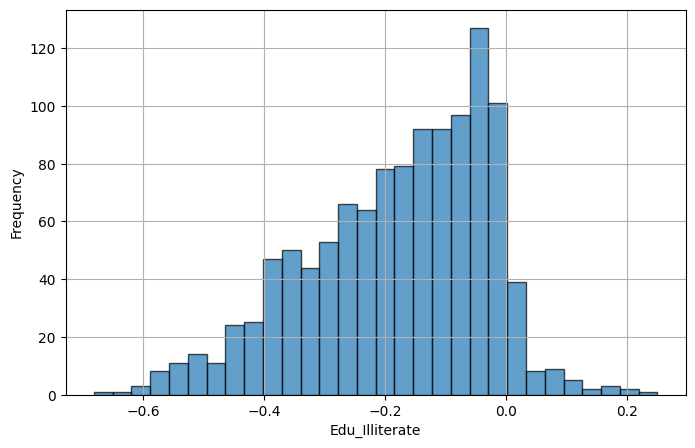

PC_dummy, 0.0655


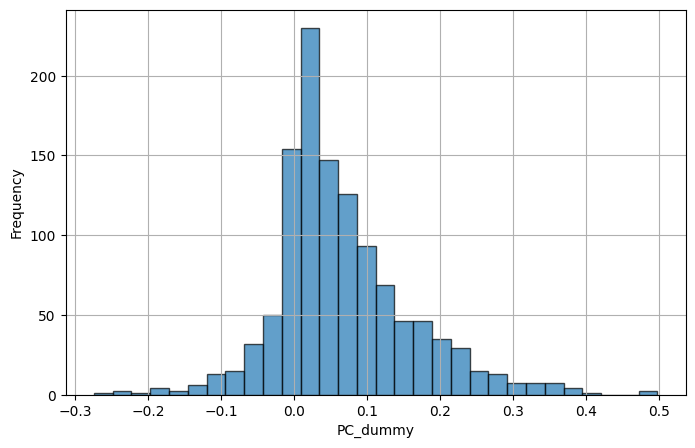

Edu_Literal, -0.0500


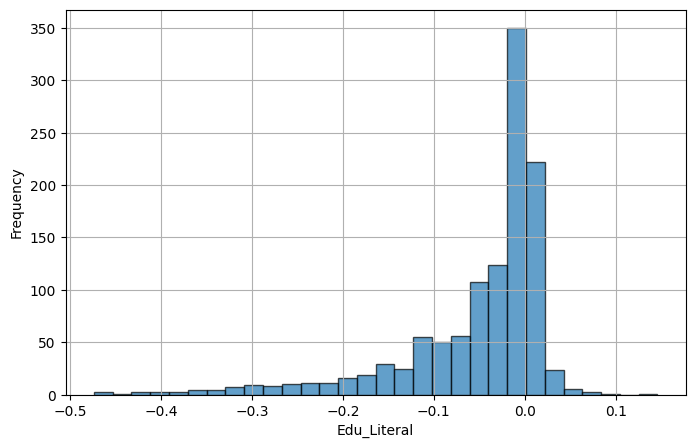

Mobile_dummy, -0.0509


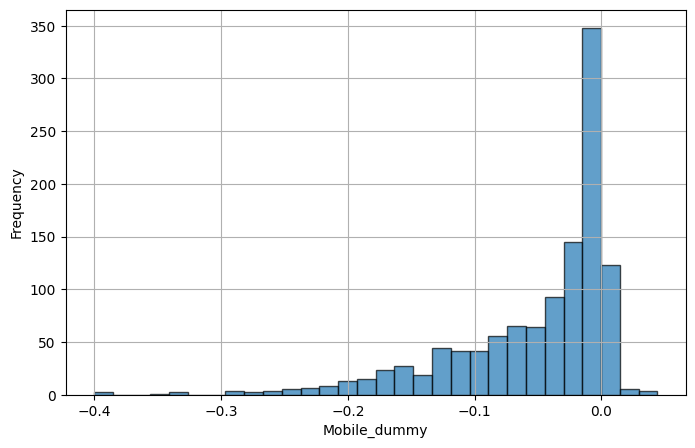

Edu_Certificate, 0.0750


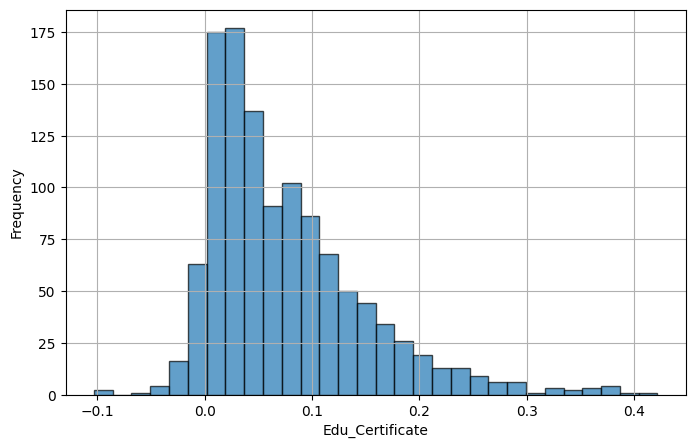

Edu_Bachelor, 0.0596


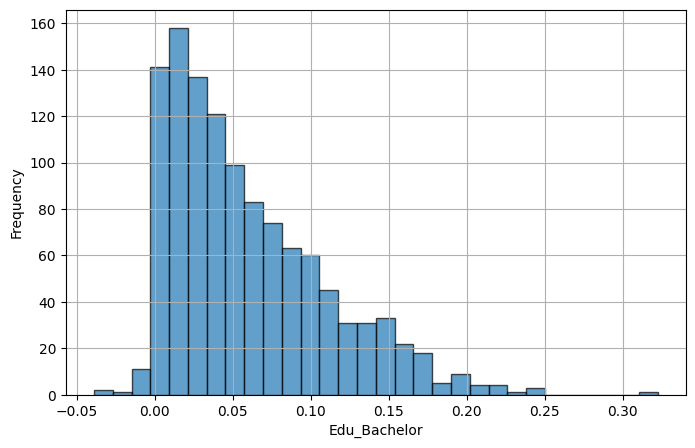

TV_dummy, 0.0334


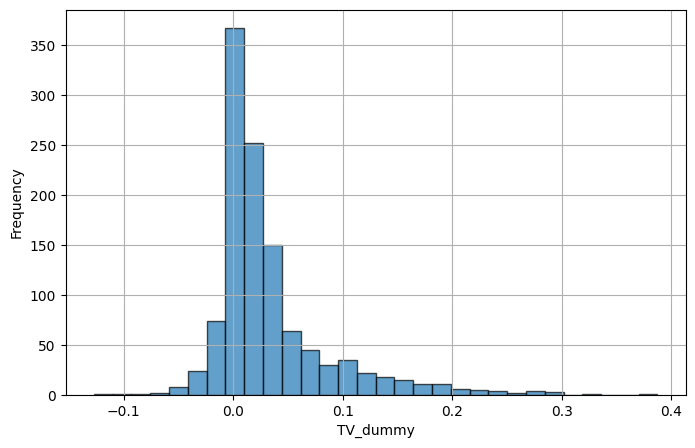

Phone_dummy, 0.0208


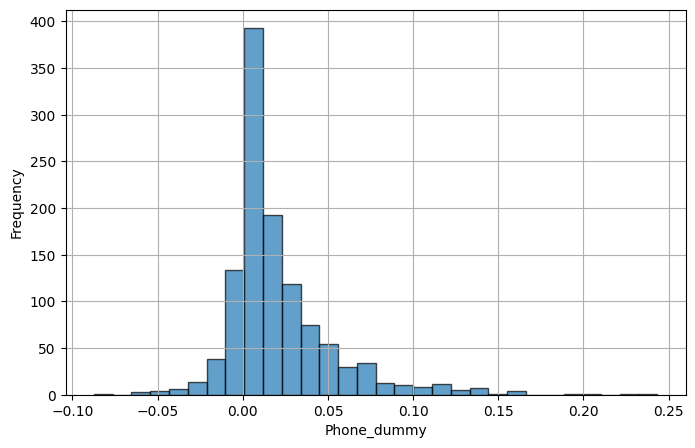

Edu_Master, 0.0596


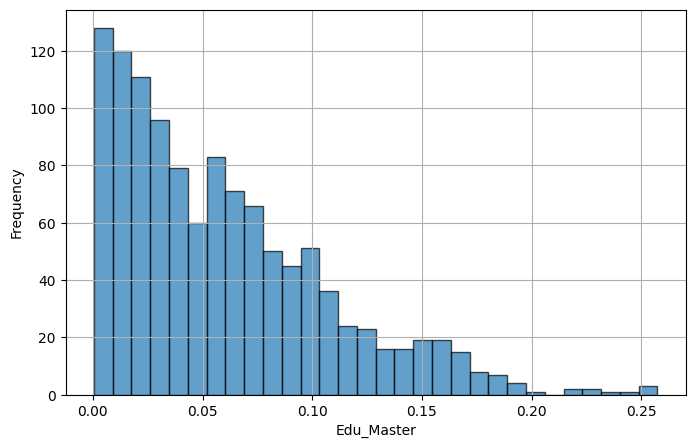

Respon_Female, -0.0873


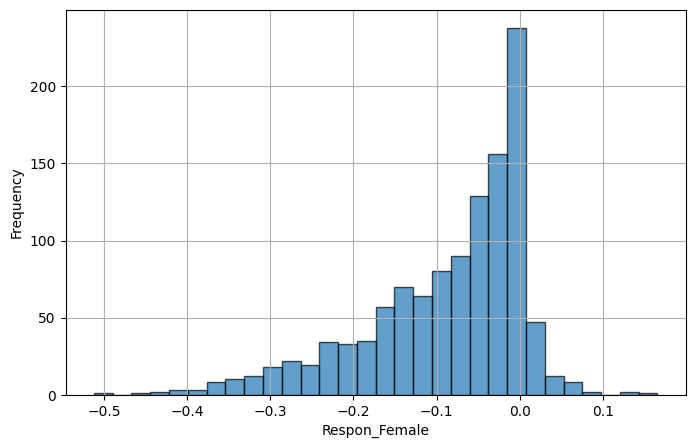

Edu_UnderSLC, 0.0302


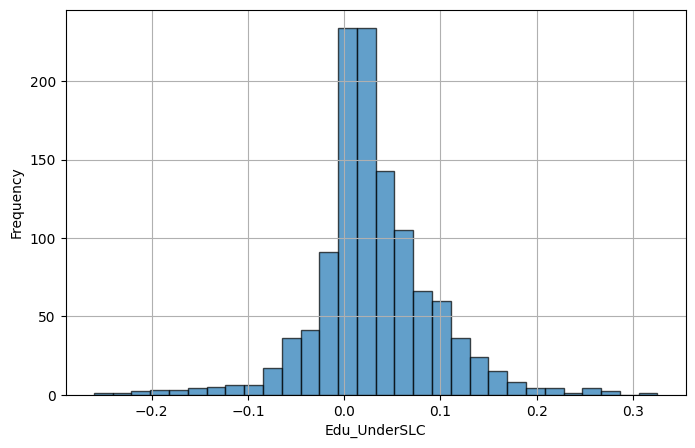

AgriSupport, 0.0344


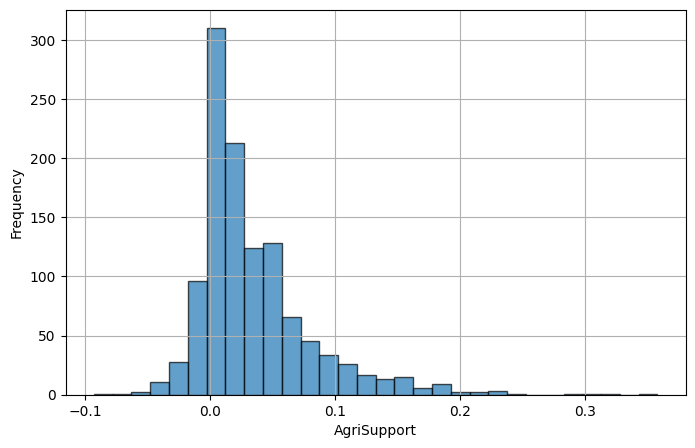

Radio_dummy, 0.0376


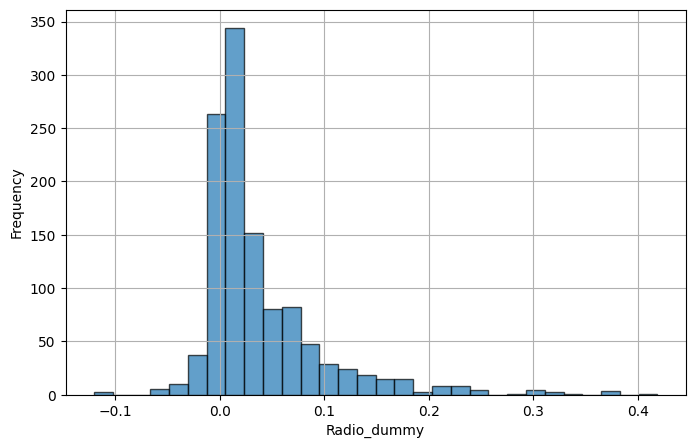

Refrige_dummy, 0.0123


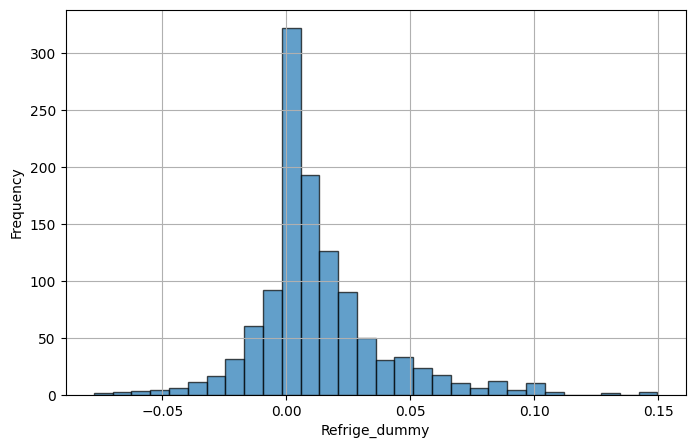

Net_dummy, 0.0152


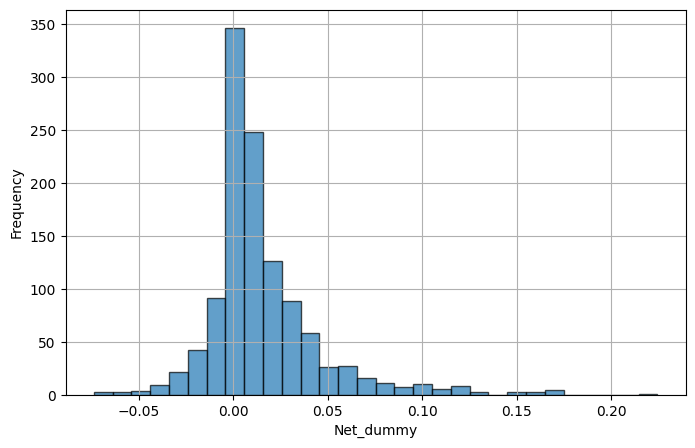

In [58]:
for name in ['Edu_Illiterate', 'PC_dummy', 'Edu_Literal', 'Mobile_dummy',
       'Edu_Certificate', 'Edu_Bachelor', 'TV_dummy',
       'Phone_dummy', 'Edu_Master', 'Respon_Female', 'Edu_UnderSLC',
       'AgriSupport', 'Radio_dummy', 'Refrige_dummy', 'Net_dummy']:
    X_test_tide = X_test.copy()
    X_test_tide[name] = 1
    y_proba_true = clf.predict_proba(X_test_tide)[:, 1]

    X_test_tide = X_test.copy()
    X_test_tide[name] = 0
    y_proba_false = clf.predict_proba(X_test_tide)[:, 1]    

    y_proba_diff = y_proba_true - y_proba_false
    print(f"{name}, {np.mean(y_proba_diff):.04f}")

    plt.figure(figsize=(8,5))
    plt.hist(y_proba_diff, bins=30, edgecolor="black", alpha=0.7)
    plt.xlabel(name)
    plt.ylabel("Frequency")
    plt.grid()
    plt.show()

In [31]:
y_proba_diff

array([-0.1053277 , -0.21896806, -0.23846263, ...,  0.21430153,
       -0.08145863, -0.41204885], dtype=float32)